# Lagrangian advection on the FESOM double gyre (daily output)

This is the FESOM counterpart of [`cmems_global/02_run_parcels.ipynb`](../cmems_global/02_run_parcels.ipynb):
seed particles in a velocity field and advect them with Parcels v4. The
difference is the grid — CMEMS is a structured (sgrid) global product, while
FESOM2 writes its horizontal velocities on the **centres of triangles** of an
unstructured mesh, so we go through the `uxarray` / UGRID path instead of
`copernicusmarine_to_sgrid`.

The double-gyre output already lives on DKRZ disk
(`/work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/`), so there is no
download step (no `01_retrieve_data` equivalent) — we read it in place.

We reuse the **cell-view linear reconstruction** developed in
[`../fesom_reconstruction/fesom_velocity_reconstruction.ipynb`](../fesom_reconstruction/fesom_velocity_reconstruction.ipynb):
the face-registered FESOM velocities are turned into a linear field per triangle
(least-squares fit to edge neighbours) instead of Parcels' piecewise-constant
default. Set `USE_RECON = False` below to fall back to the built-in interpolator.

> **Environment** — run this with the `fesom-reconstruction` pixi environment
> (`../fesom_reconstruction/pixi.toml`): Parcels v4 + uxarray. From that folder,
> `pixi run kernel` registers the Jupyter kernel.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import parcels
import uxarray as ux
import xarray as xr
from uxarray.constants import INT_FILL_VALUE

print("parcels", parcels.__version__)
print("uxarray", ux.__version__)

parcels 3.1.3.dev2090
uxarray 2026.4.1


/tmp/ipykernel_694322/292018606.py:6: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


## Parameters

`fesom.mesh.diag.nc` provides the mesh topology (the UGRID grid); the `u`/`v`/`w`
files carry the daily velocity snapshots for 1950. FESOM stores `u`, `v` on
**elements** (triangle centres → Parcels faces) and `w` on **nodes**; that is
exactly what the reconstruction kernel expects. The `unod`/`vnod` files are the
node-interpolated horizontals — we do *not* use them here.

`MESH` must match how the double-gyre coordinates are stored. Idealised FESOM
double-gyre setups are usually on a sphere in degrees (`"spherical"`); if the
inspection cell below shows coordinates that are not longitudes/latitudes (e.g.
metres or a small Cartesian box), switch to `"flat"`.

In [2]:
DATA_ROOT = Path("/work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7")
FREQ = "1d"  # daily output

GRID_PATH = str(DATA_ROOT / "fesom.mesh.diag.nc")
DATA_PATHS = [str(DATA_ROOT / FREQ / f"{v}.fesom.1950.nc") for v in ("u", "v", "w")]

MESH = "spherical"  # set to "flat" if coords are Cartesian (see inspection cell)
USE_RECON = False  # cell-view linear reconstruction vs. piecewise-constant default
N_SURFACE_LEVELS = 3  # keep only the top few layers in memory (surface advection)

print("grid:", GRID_PATH)
for p in DATA_PATHS:
    print("data:", p)

grid: /work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/fesom.mesh.diag.nc
data: /work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/1d/u.fesom.1950.nc
data: /work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/1d/v.fesom.1950.nc
data: /work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/1d/w.fesom.1950.nc


## Reconstruction kernel

Lifted verbatim from the reconstruction notebook (and `icon/profile_icon.py`):
purely geometric least-squares gradient coefficients computed once and cached on
the `uxgrid`, plus the interpolator that reads them back. See that notebook for
the derivation.

In [3]:
DEG2M = 1852.0 * 60.0  # metres per degree (matches Ux_Velocity unit conversion)


def local_offsets(mesh, lon_c, lat_c, lon, lat):
    # local planar offset (dx, dy) of (lon, lat) from centroid (lon_c, lat_c)
    if mesh == "spherical":
        dlon = ((np.asarray(lon) - lon_c + 180.0) % 360.0) - 180.0
        dx = dlon * np.cos(np.deg2rad(lat_c)) * DEG2M
        dy = (np.asarray(lat) - lat_c) * DEG2M
    else:  # flat mesh: coordinates are already a planar (x, y)
        dx = np.asarray(lon) - lon_c
        dy = np.asarray(lat) - lat_c
    return dx, dy


def build_reconstruction_terms(uxgrid, mesh):
    """Cache cell-view least-squares gradient coefficients on uxgrid._ds."""
    nbr = np.asarray(uxgrid.face_face_connectivity.values)  # (F, K)
    flon = np.asarray(uxgrid.face_lon.values)
    flat = np.asarray(uxgrid.face_lat.values)

    valid = nbr != INT_FILL_VALUE
    nbr_safe = np.where(valid, nbr, 0)

    dx, dy = local_offsets(
        mesh, flon[:, None], flat[:, None], flon[nbr_safe], flat[nbr_safe]
    )
    dx = np.where(valid, dx, 0.0)
    dy = np.where(valid, dy, 0.0)

    X2 = np.sum(dx * dx, axis=1)
    Y2 = np.sum(dy * dy, axis=1)
    XY = np.sum(dx * dy, axis=1)
    d = X2 * Y2 - XY * XY

    ok = d != 0.0  # < 2 independent neighbours -> zero-gradient fallback
    inv_d = np.where(ok, 1.0 / np.where(ok, d, 1.0), 0.0)

    gx = (dx * Y2[:, None] - dy * XY[:, None]) * inv_d[:, None]
    gy = (dy * X2[:, None] - dx * XY[:, None]) * inv_d[:, None]
    gx = np.where(valid, gx, 0.0)
    gy = np.where(valid, gy, 0.0)

    dims = ("n_face", "n_max_face_faces")
    uxgrid._ds["gradient_coeff_x"] = xr.DataArray(gx, dims=dims)
    uxgrid._ds["gradient_coeff_y"] = xr.DataArray(gy, dims=dims)
    uxgrid._ds["recon_face_neighbors"] = xr.DataArray(nbr_safe, dims=dims)
    uxgrid._ds["recon_neighbor_mask"] = xr.DataArray(valid.astype(np.float64), dims=dims)
    return uxgrid


def LinearFaceRecon(particle_positions, grid_positions, field):
    ti = grid_positions["T"]["index"]
    zi = grid_positions["Z"]["index"]
    fi = grid_positions["FACE"]["index"]

    uxg = field.grid.uxgrid
    gx = uxg._ds["gradient_coeff_x"].values[fi]  # (M, K)
    gy = uxg._ds["gradient_coeff_y"].values[fi]
    nb = uxg._ds["recon_face_neighbors"].values[fi]
    mask = uxg._ds["recon_neighbor_mask"].values[fi]

    uc = field.data.values[ti, zi, fi]  # (M,)
    un = field.data.values[ti[:, None], zi[:, None], nb]  # (M, K)
    du = (un - uc[:, None]) * mask
    ax = np.sum(gx * du, axis=1)
    ay = np.sum(gy * du, axis=1)

    flon = uxg.face_lon.values[fi]
    flat = uxg.face_lat.values[fi]
    dx, dy = local_offsets(
        field.grid._mesh, flon, flat, particle_positions["lon"], particle_positions["lat"]
    )
    return uc + ax * dx + ay * dy

In [4]:
def cell_to_vertex(u_cell, uxgrid):
    mask       = uxgrid.node_face_connectivity.values != INT_FILL_VALUE   # (n_node, max_faces)
    safe_idx   = np.where(mask, uxgrid.node_face_connectivity.values, 0)  # (n_node, max_faces)

    face_areas = uxgrid.face_areas.values[safe_idx]        # (n_node, max_faces)
    face_areas = np.where(mask, face_areas, 0.0)
    total_area = face_areas.sum(axis=1)                    # (n_node,)

    nt, nz, _ = u_cell.shape

    n_node = mask.shape[0]
    out = np.empty((nt, nz, n_node), dtype=np.float64)

    for t in range(nt):
        slab = u_cell.values[t][:, safe_idx]               # (nz, n_node, max_faces)
        slab = np.where(mask, slab, 0.0)
        out[t] = (face_areas * slab).sum(axis=-1) / total_area

    # Infer time and level dim names from the input DataArray
    time_dim, level_dim, _ = u_cell.dims

    return xr.DataArray(out, dims=[time_dim, level_dim, "n_node"])

## Build the FieldSet

`ux.open_mfdataset(grid, data)` reads the mesh topology together with the daily
velocity files; `fesom_to_ugrid` renames the FESOM dimensions to the UGRID names
Parcels expects (`nz1 -> zc`, etc.). We keep only `U`, `V`, `W` and slice to the
top `N_SURFACE_LEVELS` layers to bound memory — the full 3-D `u`/`v` are ~3.8 GB
each.

In [6]:
if USE_RECON:
    fds = ux.open_mfdataset(GRID_PATH, DATA_PATHS).rename_vars({"u": "U", "v": "V", "w": "W"}).load()
else:
    fds = ux.open_mfdataset(GRID_PATH, DATA_PATHS).load()
    fds['U'] = cell_to_vertex(fds['u'], fds.uxgrid)
    fds.drop_vars('u')
    fds['V'] = cell_to_vertex(fds['v'], fds.uxgrid)
    fds.drop_vars('v')

fds = parcels.convert.fesom_to_ugrid(fds)
fds

INFO: Using known vertical dimension mapping: 'nz' (interfaces) and 'nz1' (centers).
INFO: Renaming vertical dimensions: {'nz': 'zf', 'nz1': 'zc'}


<xarray.UxDataset> Size: 20GB
Dimensions:  (zc: 40, time: 365, n_face: 73702, zf: 41, n_node: 37239)
Coordinates:
  * zc       (zc) float64 320B 4.519 14.01 24.45 ... 3.459e+03 3.814e+03
  * time     (time) datetime64[ns] 3kB 1950-01-01T23:50:00 ... 1950-12-31T23:...
  * zf       (zf) float64 328B 0.0 9.038 18.98 ... 3.29e+03 3.628e+03 4e+03
Dimensions without coordinates: n_face, n_node
Data variables:
    u        (time, zc, n_face) float32 4GB 0.08384 -0.1518 ... -0.001951
    v        (time, zc, n_face) float32 4GB 0.2584 0.1794 ... -0.003294
    w        (time, zf, n_node) float32 2GB -3.778e-08 -3.747e-08 ... nan nan
    U        (time, zc, n_node) float64 4GB -0.03404 0.146 ... -6.461e-05
    V        (time, zc, n_node) float64 4GB 0.2189 0.3073 ... -0.003218 -0.00323
Attributes: (12/18)
    title:                               FESOM2 output
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       9aa93f20
    FESOM_MeshPath:                      /gxfs_work/geomar/smomw018/INPUT/FES...
    FESOM_mesh_representative_checksum:  
    ...                                  ...
    FESOM_use_floatice:                  0
    FESOM_whichEVP:                      0
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      5
    FESOM_use_wsplit:                    0
    FESOM_autorotate_back_to_geo:        0

In [7]:
# Inspect coordinates to confirm MESH ("spherical" vs "flat") and the domain.
print("vertical centers zc (m):", np.asarray(fds.zc.values)[:5], "...")
print("n time steps:", fds.sizes.get("time"))
g = fds.uxgrid
print(f"lon range: {float(g.node_lon.min()):.3f} .. {float(g.node_lon.max()):.3f}")
print(f"lat range: {float(g.node_lat.min()):.3f} .. {float(g.node_lat.max()):.3f}")
print(f"{g.n_face} faces (elements), {g.n_node} nodes")

vertical centers zc (m): [ 4.51883 14.00838 24.44685 35.9292  48.5598 ] ...
n time steps: 365
lon range: 0.000 .. 34.842
lat range: 15.183 .. 49.846
73702 faces (elements), 37239 nodes


In [10]:
# Surface layers only -> much smaller in-memory footprint.
fesom = parcels.FieldSet.from_ugrid_conventions(fds, mesh=MESH)

if USE_RECON:
    build_reconstruction_terms(fesom.fields["U"].grid.uxgrid, mesh=MESH)
    fesom.fields["U"].interp_method = LinearFaceRecon
    fesom.fields["V"].interp_method = LinearFaceRecon
    n_nbr = fesom.fields["U"].grid.uxgrid._ds["recon_neighbor_mask"].values.sum(axis=1)
    print(f"reconstruction on: {(n_nbr == 3).sum()} interior (3-neighbour) triangles")
else:
    print("using built-in piecewise-constant face interpolator")

fesom

INFO: cf_xarray found variable 'w' with CF standard name 'w' in dataset, renamed it to 'W' for Parcels simulation.
using built-in piecewise-constant face interpolator


<FieldSet>
    fields:
        <Field 'U'>
            Parcels attributes:
                name            : 'U'
                interp_method   : <function UxLinearNodeConstantZC at 0x1553f86a7c40>
                time_interval   : TimeInterval(left=np.datetime64('1950-01-01T23:50:00.000000000'), right=np.datetime64('1950-12-31T23:50:00.000000000'))
                igrid           : -1
            DataArray:
                <xarray.UxDataArray 'U' (time: 365, zc: 40, n_node: 37239)> Size: 4GB
                -0.03404 0.146 0.3063 0.4096 0.512 ... -0.002569 -0.002733 -0.002305 -6.461e-05
                Coordinates:
                  * time     (time) datetime64[ns] 3kB 1950-01-01T23:50:00 ... 1950-12-31T23:...
                  * zc       (zc) float64 320B 4.519 14.01 24.45 ... 3.459e+03 3.814e+03
                Dimensions without coordinates: n_node
        <Field 'V'>
            Parcels attributes:
                name            : 'V'
                interp_method   : <function U

## Seed particles

We lay a regular lon/lat grid of particles across the interior of the domain
(derived from the mesh extents, with a small margin to avoid boundary triangles)
and release them at the surface at the first available time. Increase
`N_LON x N_LAT` to scale up the experiment.

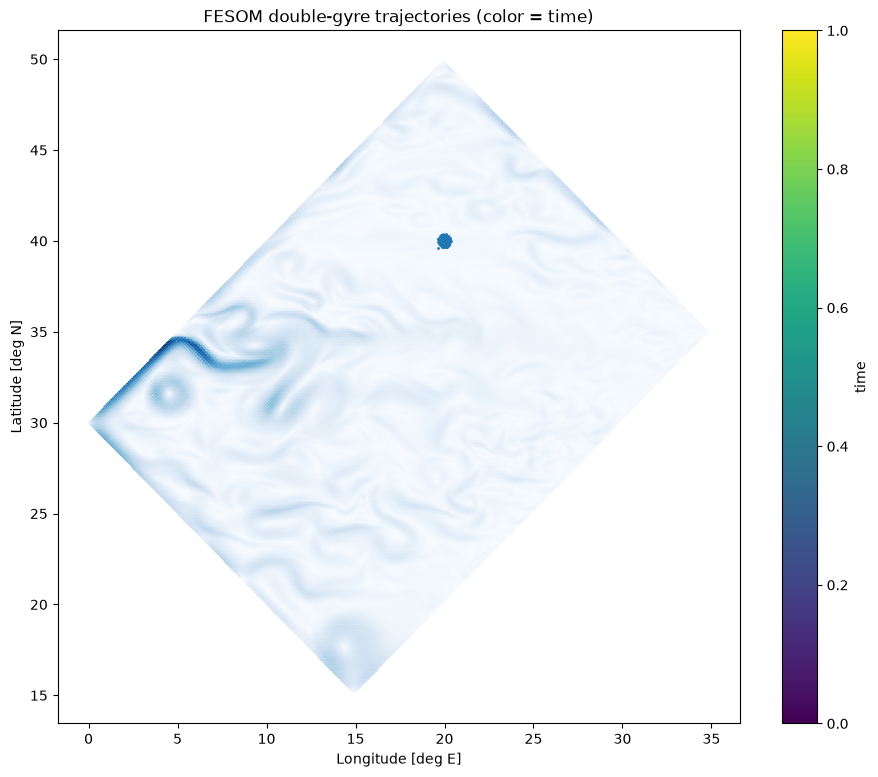

In [17]:
def gaussian_2d_points(n_points, x0, y0, R, seed=None):
    """
    Generate 2D points whose density follows a Gaussian centered on (x0, y0)
    with length scale R (standard deviation).

    Parameters
    ----------
    n_points : int
        Number of points to generate.
    x0, y0 : float
        Center of the Gaussian distribution.
    R : float
        Length scale (standard deviation) of the Gaussian.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    x, y : ndarray
        Arrays of shape (n_points,) with the sampled coordinates.
    """
    rng = np.random.default_rng(seed)
    x = rng.normal(loc=x0, scale=R, size=n_points)
    y = rng.normal(loc=y0, scale=R, size=n_points)
    return x, y

x0 = 20.0
y0 = 40.0
R = 0.1
lon_grid, lat_grid = gaussian_2d_points(5000, x0, y0, R, seed=None)

z_surface = float(fds.zc.values[0])
t0 = fds.time.values[0]

pset = parcels.ParticleSet(
    fesom,
    pclass=parcels.Particle,
    lon=lon_grid.ravel(),
    lat=lat_grid.ravel(),
    z=np.full(lon_grid.size, z_surface),
    time=np.full(lon_grid.size, t0),
)
g = fesom.fields["U"].grid.uxgrid
triang = mtri.Triangulation(
    g.node_lon.values, g.node_lat.values, triangles=g.face_node_connectivity.values
)
speed = np.hypot(
    np.asarray(fds["u"].isel(time=0, zc=0)).squeeze(),
    np.asarray(fds["v"].isel(time=0, zc=0)).squeeze(),
)

fig, ax = plt.subplots(figsize=(11, 9))
ax.tripcolor(triang, facecolors=speed, shading="flat", cmap="Blues", alpha=0.7)

sc = ax.scatter(
    lon_grid, lat_grid, s=1,
)
ax.set_xlabel("Longitude [deg E]" if MESH == "spherical" else "x")
ax.set_ylabel("Latitude [deg N]" if MESH == "spherical" else "y")
ax.set_title("FESOM double-gyre trajectories (color = time)")
fig.colorbar(sc, ax=ax, label="time")
plt.show()

## Run the advection

Daily fields, so a daily output cadence over ~30 days with a short internal
time step. Adjust `runtime` up to the length of the 1950 record.

In [18]:
output_file = parcels.ParticleFile(
    "fesom_double_gyre_trajectories.parquet",
    outputdt=np.timedelta64(1, "D"),
    mode="w",
)

pset.execute(
    [parcels.kernels.AdvectionRK4],
    runtime=np.timedelta64(360, "D"),
    dt=np.timedelta64(10, "m"),
    
    output_file=output_file,
)

INFO: Output files are stored in fesom_double_gyre_trajectories.parquet

   0%|          | [00:00<?, ?it/s]
Integration time: 1950-01-01T23:50:00   0%|          | [00:00<?, ?it/s]
Integration time: 1950-01-01T23:50:00   0%|          | [00:03<?, ?it/s]
Integration time: 1950-01-01T23:50:00   0%|          | [00:03<23:47, 21732.03it/s]
Integration time: 1950-01-02T23:50:00   0%|          | [00:07<23:47, 21732.03it/s]
Integration time: 1950-01-02T23:50:00   1%|          | [00:07<23:38, 21807.85it/s]
Integration time: 1950-01-03T23:50:00   1%|          | [00:11<23:38, 21807.85it/s]
Integration time: 1950-01-03T23:50:00   1%|          | [00:11<23:32, 21836.41it/s]
Integration time: 1950-01-04T23:50:00   1%|          | [00:15<23:32, 21836.41it/s]
Integration time: 1950-01-04T23:50:00   1%|          | [00:15<23:28, 21842.40it/s]
Integration time: 1950-01-05T23:50:00   1%|          | [00:19<23:28, 21842.40it/s]
Integration time: 1950-01-05T23:50:00   1%|▏         | [00:19<23:25, 21827.03it/s]
I

In [19]:
df = parcels.read_particlefile("fesom_double_gyre_trajectories.parquet")
df

time,z,lat,lon,particle_id
datetime[ns],f32,f32,f32,i64
1950-01-01 23:50:00,4.51883,40.189262,20.063141,0
1950-01-01 23:50:00,4.51883,40.283035,19.948309,1
1950-01-01 23:50:00,4.51883,39.866356,19.995806,2
1950-01-01 23:50:00,4.51883,39.917774,20.092199,3
1950-01-01 23:50:00,4.51883,39.915195,20.086988,4
…,…,…,…,…
1950-12-27 23:50:00,4.51883,42.742493,13.866197,4995
1950-12-27 23:50:00,4.51883,46.884449,-0.659719,4996
1950-12-27 23:50:00,4.51883,48.183693,-0.632654,4997


## Plot the trajectories over the surface speed field

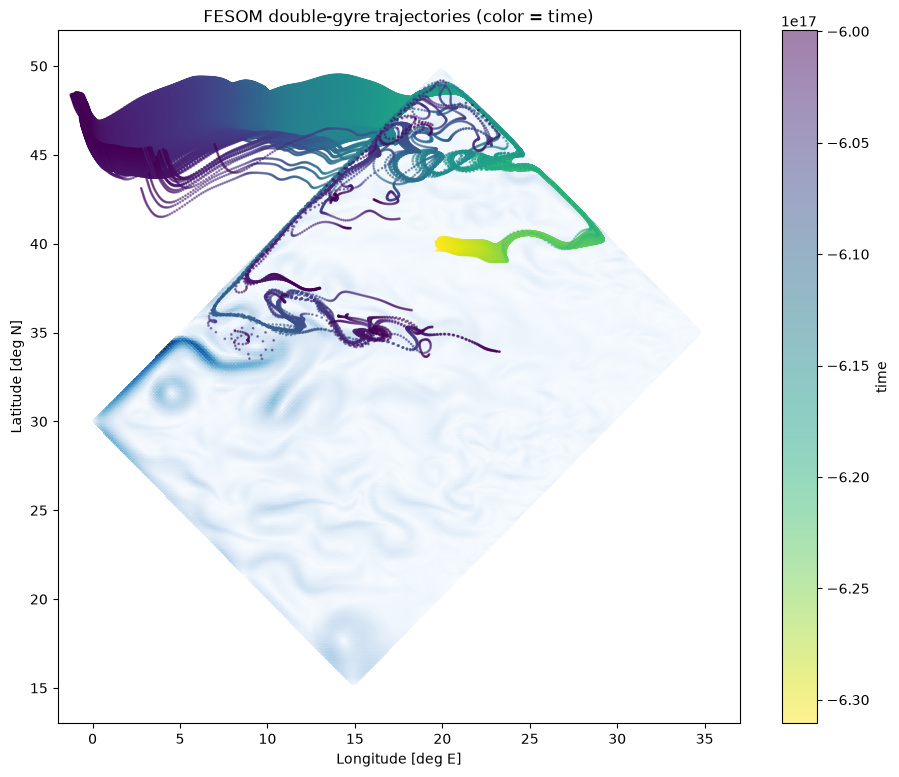

In [20]:
triang = mtri.Triangulation(
    g.node_lon.values, g.node_lat.values, triangles=g.face_node_connectivity.values
)
speed = np.hypot(
    np.asarray(fds["u"].isel(time=0, zc=0)).squeeze(),
    np.asarray(fds["v"].isel(time=0, zc=0)).squeeze(),
)

fig, ax = plt.subplots(figsize=(11, 9))
ax.tripcolor(triang, facecolors=speed, shading="flat", cmap="Blues", alpha=0.7)

_df = df.to_pandas().sort_values("time")
sc = ax.scatter(
    _df["lon"], _df["lat"], c=_df["time"], s=1, alpha=0.5, cmap="viridis_r"
)
ax.set_xlabel("Longitude [deg E]" if MESH == "spherical" else "x")
ax.set_ylabel("Latitude [deg N]" if MESH == "spherical" else "y")
ax.set_title("FESOM double-gyre trajectories (color = time)")
plt.xlim((-2,37))
plt.ylim((13,52))
fig.colorbar(sc, ax=ax, label="time")
plt.show()